# Capstone: Define and Solve an ML Problem

In [2]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

ModuleNotFoundError: No module named 'tensorflow'

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [ ]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "../..", "data", "censusData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename, header=0)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the census Dataset.
2. The label is the income_binary column. The model will be predicting whether an individual's annual income exceeds $50,000; therefore, it's a binary classification problem.
3. From the data I see upfront, I plan to use age, workclass, fnlwgt, education, marital-status, sex_selfID, and hours-per-week as features, as heuristically, these factors affect how much income a person has.
4. This problem matters to underserved communities who may qualify for low-interest loans and financial education programs, and having the model to predict the income will allow the organization to increase their number of outreach to qualifying people, benefitting both the orgnization and the selected person.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<AxesSubplot:xlabel='income_binary', ylabel='Count'>

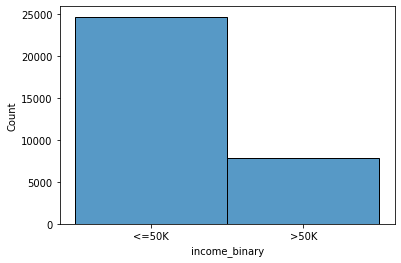

In [3]:
df.groupby("income_binary").size()
sns.histplot(data=df, x="income_binary")

A huge inbalance in income label is observed, and that makes sense if we think that there's less high-income individuals than low-income individuals.

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [4]:
# Check num rows and columns in data
df.shape

(32561, 15)

The summary statistics of all features, indicates the following:
- The count row tells us that feature including age, workclass, occupation, hours-per-week, and native-country has missing values.
- mean is much higher than the median in features "capital-gain" and "capital-loss", which indicates the possible presence of outliers.


#### Summary Statistics

In [5]:
# Check summary statistics for the DataFrame
df.describe(include = "all")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
count,32399.000000,30725,3.256100e+04,32561,32561.000000,32561,30718,32561,32561,32561,32561.000000,32561.000000,32236.000000,31978,32561
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Non-Female,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.589216,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,615.907773,87.303830,40.450428,NaN,NaN
std,13.647862,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,2420.191974,402.960219,12.353748,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


#### Missing Values

With `nan_percentage`, we can see how much percentage of the data are missing from the columns with NaN values.

In [6]:
nan_df = np.sum(df.isnull(), axis = 0)
nan_percentage = (nan_df[nan_df != 0] / df.shape[0]) * 100
print("Percentage of Missing Data in columns")
print(nan_percentage)

Percentage of Missing Data in columns
age               0.497528
workclass         5.638647
occupation        5.660146
hours-per-week    0.998127
native-country    1.790486
dtype: float64


#### Type Check for Label Column

Label column is a string type. It should be changed to a boolean type.

In [7]:
df['income_binary'].dtype

dtype('O')

#### Outliers in capital-gain feature

"capital-gain" feature with values > 0 has balanced income_binary for both >50K and <=50K.  
This indicates that it's worth considering "captial-gain" feature into consideration without any modifications, as having a capital gain < 0 and > 0 could both produce different incomes.

In [8]:
good_income_condition = (df['capital-gain'] > 0) & (df['income_binary'] == '<=50K')
print("capital-gain > 0 & income_binary <= 50K: ", df[good_income_condition].shape[0], "examples")

bad_income_condition = (df['capital-gain'] > 0) & (df['income_binary'] == '>50K')
print("capital-gain > 0 & income_binary > 50K: ", df[bad_income_condition].shape[0], "examples")

capital-gain > 0 & income_binary <= 50K:  1035 examples
capital-gain > 0 & income_binary > 50K:  1677 examples


Same applies to capital-loss feature, so this feature should also be considered without any modifications.

In [9]:
good_income_condition = (df['capital-loss'] > 0) & (df['income_binary'] == '<=50K')
print("capital-loss > 0 & income_binary <= 50K: ", df[good_income_condition].shape[0], "examples")

bad_income_condition = (df['capital-loss'] > 0) & (df['income_binary'] == '>50K')
print("capital-loss > 0 & income_binary > 50K: ", df[bad_income_condition].shape[0], "examples")

capital-loss > 0 & income_binary <= 50K:  746 examples
capital-loss > 0 & income_binary > 50K:  773 examples


#### Data Distributions

In the age distributions, we could see that some people with certain ages populates the dataset more than the rest, and most of the data are heavily crowded on the left side of the histogram, which aligns with reality, as most workers are middle-aged people.

<AxesSubplot:xlabel='age', ylabel='Count'>

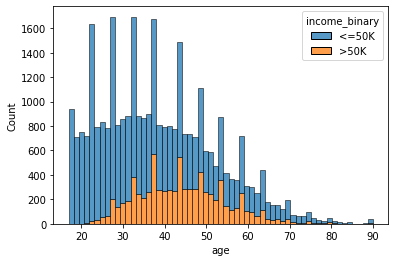

In [10]:
sns.histplot(data=df, x="age", hue="income_binary", multiple="stack")

The education-num distribution is a normal distribution, and the small percentile for people with 1 years of education are all <= 50K income, so there's no problem in this data.

<AxesSubplot:xlabel='education-num', ylabel='Count'>

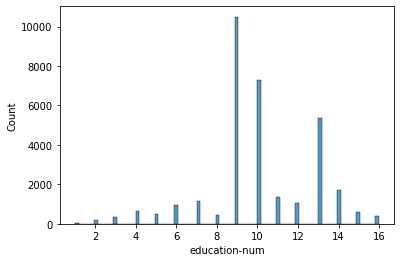

In [11]:
sns.histplot(data=df, x="education-num")

In [12]:
edu_num_1 = np.percentile(df['education-num'], 0.01)
print("years of education for 0.01 percentile:", edu_num_1, "years")

good_income_condition = (df['education-num'] <= 1) & (df['income_binary'] == "<=50K")
print("education-num < 1 & income <=50K:",df[good_income_condition].shape[0], "examples")
bad_income_condition = (df['education-num'] <= 1) & (df['income_binary'] == ">50K")
print("education-num < 1 & income >50K:",df[bad_income_condition].shape[0], "examples")

years of education for 0.01 percentile: 1.0 years
education-num < 1 & income <=50K: 51 examples
education-num < 1 & income >50K: 0 examples


hours-per-week column has some outliers of 99 hours which should be handled.

<AxesSubplot:xlabel='hours-per-week', ylabel='Count'>

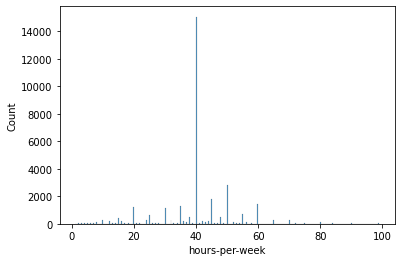

In [13]:
sns.histplot(data=df, x="hours-per-week")

A huge amount of people surveyed are white people, which makes the data overfitted to the population of white people.

In [14]:
df['race'].value_counts(normalize=True) * 100

White                 85.427352
Black                  9.594300
Asian-Pac-Islander     3.190934
Amer-Indian-Inuit      0.955130
Other                  0.832284
Name: race, dtype: float64

#### Correlations between features

Check correlation for features. The label feature is still an object type at this point, so we can't see the label feature in here.

In [15]:
df.corr()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076267,0.036761,0.124901,0.057545,0.067066
fnlwgt,-0.076267,1.000000,-0.043195,-0.002234,-0.010252,-0.018130
education-num,0.036761,-0.043195,1.000000,0.167089,0.079923,0.147256
capital-gain,0.124901,-0.002234,0.167089,1.000000,-0.055138,0.101594
capital-loss,0.057545,-0.010252,0.079923,-0.055138,1.000000,0.054500
hours-per-week,0.067066,-0.018130,0.147256,0.101594,0.054500,1.000000


For the sake of seeing the correlations between labels and features, we'll change the label column to a boolean type, and change the label name to "income<=50K"

In [16]:
df['income_binary'] = df['income_binary'] == "<=50K"
df = df.rename(columns={'income_binary': 'income<=50K'})

In [17]:
print("Testing if both True and False are included in 'income<=50K': ", df['income<=50K'].unique())

Testing if both True and False are included in 'income<=50K':  [ True False]


In [18]:
df.corr()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income<=50K
age,1.000000,-0.076267,0.036761,0.124901,0.057545,0.067066,-0.233638
fnlwgt,-0.076267,1.000000,-0.043195,-0.002234,-0.010252,-0.018130,0.009463
education-num,0.036761,-0.043195,1.000000,0.167089,0.079923,0.147256,-0.335154
capital-gain,0.124901,-0.002234,0.167089,1.000000,-0.055138,0.101594,-0.347555
capital-loss,0.057545,-0.010252,0.079923,-0.055138,1.000000,0.054500,-0.150526
hours-per-week,0.067066,-0.018130,0.147256,0.101594,0.054500,1.000000,-0.229523
income<=50K,-0.233638,0.009463,-0.335154,-0.347555,-0.150526,-0.229523,1.000000


The correlation between numerical features and the label is low, but the lowest one is 'fnlwgt', and the correlation of less than 0.1 would not contribute much to the prediction, so this column 'fnlwgt' should be dropped.  

Otherwise, the correlations are in good shape, and each feature also have correlation less than 0.85, which indicates that the features are independent.

#### Features with String Values

We'll check the features with string values to see which features are worth one-hot encoding.

In [19]:
print("Columns with string values:")
list(df.select_dtypes(include="object").columns)

Columns with string values:


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex_selfID',
 'native-country']

In [20]:
print("String Categories of workclass:")
df['workclass'].unique()

String Categories of workclass:


array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', nan, 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [21]:
print("String Categories of education:")
df['education'].unique()

String Categories of education:


array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

In [22]:
print("String Categories of marital-status:")
df['marital-status'].unique()

String Categories of marital-status:


array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

In [23]:
print("String Categories of occupation:")
df['occupation'].unique()

String Categories of occupation:


array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', nan, 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [24]:
print("String Categories of relationship:")
df['relationship'].unique()

String Categories of relationship:


array(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

In [25]:
print("String Categories of race:")
df['race'].unique()

String Categories of race:


array(['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Inuit',
       'Other'], dtype=object)

In [26]:
print("String Categories of sex_selfID:")
df['sex_selfID'].unique()

String Categories of sex_selfID:


array(['Non-Female', 'Female'], dtype=object)

In [27]:
print("String Categories of native-country:")
df['native-country'].unique()

String Categories of native-country:


array(['United-States', 'Cuba', 'Jamaica', 'India', nan, 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

For the native-country feature, we can reduce it down to United-States natives, non United-States natives, and Unknowns. We can replace the values with "United-States", "not United-States", and "Unknowns", so that there'll be far less columns to do one-hot encoding.

From the object features, we could see that the martial-status and relationship are very similar features, and heuristically, incorporating one feature would be enough to make the prediction. For that, I'll choose the martial-status feature and drop the relationship feature. 

All object features appear to be informational to make the prediction, so we can one-hot encode all object features.

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

There is a big data imbalance observed in the label column, which aligns with the reality of having more poor people than rich people, but to prevent the problem of overfitting, we'd have to rely on precision and recall for evaluation of the model instead of the accuracy. I can also adjust the hyperparameter for the model to have `class_weight='balanced'` without manipulating the data.

The dataset has missing values in features columns such as age, workclass, occupation, hours-per-week, and native-country. The age column has a very small percentage of its data missing, and to avoid manipulating the data, we can safely delete those examples where age is missing. For workclass, occupation and native-country features, we can replace the missing values with "Unknown", and account that missing value into consideration for predictions. For hours-per-week, we can impute the missing values with the mean hours. Thus, all missing values in the dataset is handled.

The label column is also observed to be an object value, and for analysis purposes, the label is already converted to a boolean with the name "income<=50K".

From the summary statistics, we observed that capital-gain and capital-loss has outlier values or skewed data, but the skewed data, which is capital-gain > 0 and capital-loss > 0, has a good balance in the label values, so I decided to not make modifications and take it has good information for model training.

We could also observe a left-skewed data for the age column and its count, which aligns with reality, so I'll take the data as is. Same applies to the education-num column.

When going through the correlations between the features and the label, I found out that 'fnlwgt' feature has a correlation less than 0.1, indicating that there's not relationship between that feature and the label, so that column will be dropped.

The features with string values are also analyzed and I'll be removing the relationship feature due to its similarity with the martial-status feature. That way redundancy is reduced when training the model.

For the native-country feature, we can reduce it down to United-States natives, non United-States natives, and Unknowns, so that there'll be far less columns to do one-hot encoding.

After that, we can one-hot encode all features with string values.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. It was observed that out of all races, 95% of the population of the data collected were white, which would make the model highly fitted for white people, and might work poorly for underserved populations in other races. The dataset is highly biased to generalize well to new unseen data.
2. Low-income individuals from underserved communities who might possibly be eliglble for CDFI's programs would be the ones badly affected, as they could miss on opportunities that could help them financially or in terms of resources that they need. For individuals with high-income, who are wrongly predicted to by low-income, it wouldn't make much of a difference in their lives having these opportunities, but for low-income individuals, missing these opportunities would be a huge loss.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

#### Handle Missing Values

Examples where age is missing will be deleted, as it only removes a very small percentage of data. Manipulating the data might mislead the model, so I believe it's best to just remove them if it's not too much.

In [28]:
df.dropna(subset=['age'], inplace=True)
print("Any missing values in age column?", df['age'].isnull().values.any())

Any missing values in age column? False


We can fill all string columns with missing values to have an "Unknown" value, and that might give insight to the model about what "Unknown" values mean to the income label.

In [29]:
obj_cols = list(df.select_dtypes(include=['object']).columns)
print("string columns:", obj_cols, "\n")
df[obj_cols] = df[obj_cols].fillna("Unknown")
print("Any missing values in string columns?", df[obj_cols].isnull().values.any())

string columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex_selfID', 'native-country'] 

Any missing values in string columns? False


hours-per-week is a very crucial column in determining the income, so I'll impute the missing values to have the mean value.

In [30]:
mean_hours = df['hours-per-week'].mean()
df['hours-per-week'].fillna(value=mean_hours, inplace=True)
print("Any missing values in hours-per-week?", df['hours-per-week'].isnull().values.any())

Any missing values in hours-per-week? False


#### Winsorize hours-per-week

hours-per-week feature also has some outliers like 99 hours, so we can use winsorization to cap the values at 1st and 99th percentile.

In [31]:
df['hours-per-week-winsorized'] = stats.mstats.winsorize(df['hours-per-week'], limits=[0.01, 0.01])
df.drop(columns='hours-per-week', inplace=True)
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex_selfID',
       'capital-gain', 'capital-loss', 'native-country', 'income<=50K',
       'hours-per-week-winsorized'],
      dtype='object')

#### Drop column

The column fnlwgt has a very low correlation to the label, so it won't contribute much to the prediction, and it should be removed.

In [32]:
df.drop(columns="fnlwgt", inplace=True)
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex_selfID', 'capital-gain',
       'capital-loss', 'native-country', 'income<=50K',
       'hours-per-week-winsorized'],
      dtype='object')

Relationship feature is redundant, so I'll remove this feature.

In [33]:
df.drop(columns="relationship", inplace=True)
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'race', 'sex_selfID', 'capital-gain', 'capital-loss',
       'native-country', 'income<=50K', 'hours-per-week-winsorized'],
      dtype='object')

#### Categorize native-country feature

All missing values are handled for native-country feature, so we just need to swap non-US countries to "not United-States" as values. This will reduce the number of columns when one-hot encode is done for native-country feature.

In [34]:
nonUS_condition = (df['native-country'] != "United-States") & (df['native-country'] != "Unknown")
df.loc[nonUS_condition, 'native-country'] = "not United-States"
df['native-country'].unique()

array(['United-States', 'not United-States', 'Unknown'], dtype=object)

#### One-Hot-Encode

All features with string values are correlated to the label, and has value to the prediction, so all these features will be one-hot encoded.

In [35]:
str_cols = list(df.select_dtypes(include="object").columns)
for col in str_cols:
    df_col = pd.get_dummies(df[col], prefix = col + '_')
    df = df.join(df_col)
    df.drop(columns=col, inplace=True)
    
df.columns

Index(['age', 'education-num', 'capital-gain', 'capital-loss', 'income<=50K',
       'hours-per-week-winsorized', 'workclass__Federal-gov',
       'workclass__Local-gov', 'workclass__Never-worked', 'workclass__Private',
       'workclass__Self-emp-inc', 'workclass__Self-emp-not-inc',
       'workclass__State-gov', 'workclass__Unknown', 'workclass__Without-pay',
       'education__10th', 'education__11th', 'education__12th',
       'education__1st-4th', 'education__5th-6th', 'education__7th-8th',
       'education__9th', 'education__Assoc-acdm', 'education__Assoc-voc',
       'education__Bachelors', 'education__Doctorate', 'education__HS-grad',
       'education__Masters', 'education__Preschool', 'education__Prof-school',
       'education__Some-college', 'marital-status__Divorced',
       'marital-status__Married-AF-spouse',
       'marital-status__Married-civ-spouse',
       'marital-status__Married-spouse-absent',
       'marital-status__Never-married', 'marital-status__Separated',
 

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

All missing values are handled, as missing values could crash the model during training process. 
- For the age column, examples with missing age are deleted, as it only removes a very small percentage of data. Manipulating the age might mislead the model, so I believe it's best to just remove them if it's not too much.
- For all the string columns with missing values, I replace "Unknown" for all missing values, as that information might be relevant to the label, and is therefore, better to keep it as "Unknown" rather than deleting it.
- For hours-per-week column, I impute the missing values to have the mean value, as this feature is a very crucial column in determining the income.

Hours-per-week column has outlier values, so I winsorized the feature to not have outliers while keeping the examples, so that our model won't be polluted with outlier values.

I dropped 2 columns: fnlwgt and relationship.
- fnlwgt has a very low correlation to the label, so it won't contribute much to the prediction, and it should be removed.
- relationship feature is redundant to martial-status feature, so I remove the relationship feature as the other one has more information.

native-country feature is categorized into "United-States", "not United-States" and "Unknown". A huge population of individuals are categorized as "United-States", and there are lots of other countries, so it's better to categorize the rest, small population as "not United-States", so that it's still counted for. 

Class imbalance is identified, but it matches with the reality, so there's nothing much to do in data preparation, until we get to model training, where we should use precision+recall metrics rather than accuracy to evaluate our models.

Finally, all string features are one-hot encoded.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [36]:
# Create labeled examples from the dataset
y = df['income<=50K']
X = df.drop(columns='income<=50K', axis=1)

In [37]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1234)

In [38]:
# Train, test and evaluate your model
model = DecisionTreeClassifier(class_weight='balanced')

model.fit(X_train, y_train)

class_label_predictions = model.predict(X_test)

DTree_acc_score = accuracy_score(y_test, class_label_predictions)
DTree_f_1_score = f1_score(y_test, class_label_predictions, average='binary')
print('Accuracy score: {0}'.format(DTree_acc_score))
print('F-1 score: {0}'.format(DTree_f_1_score))

Accuracy score: 0.8145679012345679
F-1 score: 0.8767438043656653


In [39]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
hyperparams_maxDepth = [2**n for n in range(6)]
hyperparams_minLeaf = [2**n for n in range(6)]
param_grid = {
    'max_depth': hyperparams_maxDepth, 
    'min_samples_leaf': hyperparams_minLeaf, 
    'class_weight': ['balanced']
}

model = DecisionTreeClassifier()
grid = GridSearchCV(model, param_grid, cv=5)
grid_search = grid.fit(X_train, y_train)
print('Optimal hyperparameters: {0}'.format(grid_search.best_params_))
print('Accuracy score: {0}'.format(grid_search.best_score_) + "\n")

grid = GridSearchCV(model, param_grid, scoring='f1', cv=5)
grid_search = grid.fit(X_train, y_train)
print('Optimal hyperparameters: {0}'.format(grid_search.best_params_))
print('F-1 score: {0}'.format(grid_search.best_score_))

Optimal hyperparameters: {'class_weight': 'balanced', 'max_depth': 32, 'min_samples_leaf': 1}
Accuracy score: 0.8110207692314206

Optimal hyperparameters: {'class_weight': 'balanced', 'max_depth': 32, 'min_samples_leaf': 1}
F-1 score: 0.8734235932108806


In [40]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
model = DecisionTreeClassifier(
    max_depth=grid_search.best_params_['max_depth'], 
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'], 
    class_weight='balanced'
)

model.fit(X_train, y_train)

class_label_predictions = model.predict(X_test)

DTree_accuracy = accuracy_score(y_test, class_label_predictions)
DTree_f1 = f1_score(y_test, class_label_predictions, average='binary')
print('Accuracy score: {0}'.format(DTree_accuracy))
print('F-1 score: {0}'.format(DTree_f1))

Accuracy score: 0.8159259259259259
F-1 score: 0.8764398773514545


In [41]:
# Interpret your model's outputs 
importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False)

# For performance analysis, group one-hot encoded columns back to their parent columns. Sum scores up.
importance_df['Parent_Feature'] = importance_df['Feature'].apply(lambda x: x.split('__')[0])
analysis_df = importance_df.groupby('Parent_Feature')['Importance Score'].sum().reset_index()
analysis_df = analysis_df.sort_values(by='Importance Score', ascending=False)
analysis_df.columns = ['Parent_Feature', 'Total Importance Score']

print(analysis_df.to_string(index=False))

            Parent_Feature  Total Importance Score
            marital-status                0.321260
                       age                0.153116
             education-num                0.111381
              capital-gain                0.104088
 hours-per-week-winsorized                0.082717
                occupation                0.078510
                 workclass                0.047017
              capital-loss                0.033225
                 education                0.023381
                      race                0.017573
                sex_selfID                0.014490
            native-country                0.013241


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I choose Decision Trees for this problem, as we could see no linear relationship between the features and the labels. I also don't need the probability of income<=50K, and there's a mix or numeric and categorical data in the dataset, so Decision Trees are the best choice to handle non-linear boundaries without extensive feature scaling.
2. Through the model selection process, I learned that the model is overfitted. When the model was trained with optimal hyperparameter values, there was a slight dip in accuracy score and F-1 score compared to simpler configurations. This was the result of noisy training set that the Decision Tree learned.
3. Looking at the feature importance scores, martial status turns out to be the largest factor by about 32% that decides the income of the person. The feature importance scores measures the score of how much each feature helped cleanly divide individuals into the <=50K or > 50K income brackets.
4. There are some concerns with using demographic attributes for model predictions. Even though demographic features only comprise around 4.7% of the model's importance scores, using them to make decisions violates legal and fair-lending standards. With the incorrect predictions (misclassifying a high-earner as <=50K), there could be lower loan offfers or higher interest rates for qualified individuals. With the 1994 Census dataset, historically marginalized groups (women and racial minorities) are more likely to be adversely affected due to historical representation bias.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [42]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [43]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=n_features, name='input')
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
# 2 layers should be enough for our non-linear data. More than 2 layers would be for Deep Learning, which is used in computer vision.
# Choosing number of units is more of an optimization problem. We'll start with 32 and gradually go down. 32, 16, 1
# ReLu activation is great at learning in the hidden layers. For binary classfication problem like this, we should have sigmoid activation at the output layer.
hidden_layer_1 = keras.layers.Dense(units=32, activation='relu', name='hl_1')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=16, activation='relu', name='hl_2')
nn_model.add(hidden_layer_2)

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units=1, activation='sigmoid', name='output')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
hl_1 (Dense)                 (None, 32)                2016      
_________________________________________________________________
hl_2 (Dense)                 (None, 16)                528       
_________________________________________________________________
output (Dense)               (None, 1)                 17        
Total params: 2,561
Trainable params: 2,561
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [44]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# A high learning rate of 0.1 will be enough to make progress in finding the wide minimum.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.1)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [45]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [46]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [47]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [48]:
# Decision: How many epochs? Add a comment.
# Huge datasets with millions of data will need less epochs, but ours will need more. 
# 100 would be a good start.

t0 = time.time() # start time

num_epochs = 100

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)],
    validation_split=0.2
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 100], Loss: 0.2903, Accuracy: 0.8642, Val_loss: 0.3197, Val_accuracy: 0.8578
Epoch [20/ 100], Loss: 0.2776, Accuracy: 0.8689, Val_loss: 0.3236, Val_accuracy: 0.8582
Epoch [30/ 100], Loss: 0.2673, Accuracy: 0.8736, Val_loss: 0.3384, Val_accuracy: 0.8537
Epoch [40/ 100], Loss: 0.2590, Accuracy: 0.8771, Val_loss: 0.3580, Val_accuracy: 0.8477
Epoch [50/ 100], Loss: 0.2544, Accuracy: 0.8823, Val_loss: 0.3679, Val_accuracy: 0.8455
Epoch [60/ 100], Loss: 0.2489, Accuracy: 0.8840, Val_loss: 0.3696, Val_accuracy: 0.8395
Epoch [70/ 100], Loss: 0.2455, Accuracy: 0.8851, Val_loss: 0.3809, Val_accuracy: 0.8471
Epoch [80/ 100], Loss: 0.2420, Accuracy: 0.8862, Val_loss: 0.4017, Val_accuracy: 0.8342
Epoch [90/ 100], Loss: 0.2385, Accuracy: 0.8894, Val_loss: 0.4057, Val_accuracy: 0.8424
Epoch [100/ 100], Loss: 0.2353, Accuracy: 0.8897, Val_loss: 0.4230, Val_accuracy: 0.8418
Elapsed time: 150.07s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



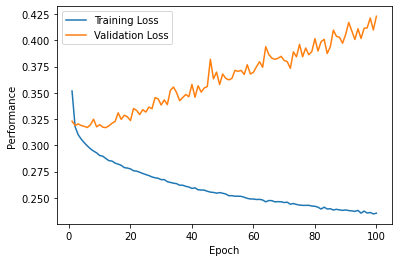

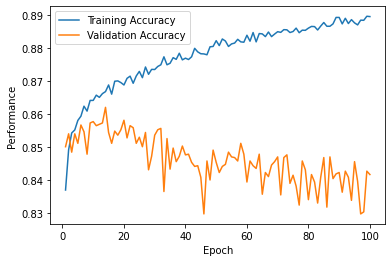

In [49]:
# Plot training loss and validation loss over epochs
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Performance')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Performance')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

Using the neural network to generate predictions on the test set and evaluate its performance with accuracy and F1 score. Used `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, applied a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Saved accuracy and F1 score results to clearly named variables so we can compare them to the results from the previous model. Printed the results.

In [50]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

probability_predictions = nn_model.predict(X_test_scaled)
nn_class_label_predictions = [1 if prob >= 0.5 else 0 for prob in probability_predictions]

In [51]:
# Compute accuracy and F1 score for the neural network and print the results
nn_accuracy = accuracy_score(y_test, nn_class_label_predictions)
nn_f1 = f1_score(y_test, nn_class_label_predictions, average='binary')
print("Accuracy Score:", nn_accuracy)
print("F-1 Score:", nn_f1)

Accuracy Score: 0.8386419753086419
F-1 Score: 0.8973694542599135


#### Neural Network Reflection:

- Architecture decisions:
    - I choose 2 layers, as datasets with non-linear boundaries generally require 2 hidden layers to capture the complexity of the features. 
    - For the number of units, using the pattern 32->16->1, so that high-dimensional input can be compressed into dense abstractions. 
    - ReLu activation is great at learning in the hidden layers. For binary classfication problem like this, we should have sigmoid activation at the output layer. 
    - A high learning rate of 0.1 for SGD will allow the model to make progress in finding the wide minimum.
    - Huge datasets with millions of data will need less epochs, but ours will need more. I choose 100, and that should be enough for the training data to converge.
- The training curves tell me that there's overfitting in data. In terms of loss, training data steadily drops, while validation steadily increases. In terms of accuracy, training data steadily increases, while validation drops. The decrese in training loss and increase in validation loss, shows that the model is learning the noise in training set.
- Performance:
    - Test Accuracy: 0.8365
    - Test F-1 score: 0.8961
    - Results were not surprising. Even though overfitting is observed, the classification boundaries remained stable enough that accuracy did not severely crash on unseen data.

## Part 7: Compare Models and Reflect

###  Results Summary

Code cell below creates a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [52]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'KNN Model': [DTree_accuracy, DTree_f1],
    'Neural Network': [nn_accuracy, nn_f1]
})
print(results.to_string(index=False))

   Metric  KNN Model  Neural Network
 Accuracy   0.815926        0.838642
 F1 Score   0.876440        0.897369


### Comparative Analysis

- The summary table revealed that Neural Networks performed better than Decision Trees in terms of both accuracy and F1 score.
- Neural Networks capture the non-linear relationship better than Decision Trees did, but nevertheless, the outcomes of neural networks are hard to explain, and it requires more time and effort to scale neural networks, so it's not worth the complexity.
- When recommending to the company tohough, I would recommend DecisionTrees, as they're more transparent with clear rules set in the model. The model is trained on sensitive demographic data, so whenever a person is deemed ineligible, the model could be audited to give a clear reason based on the rules set by the Decision Tree. It's also less costly than Neural Networks. 
- I could improve the results by first of all, removing the sensitive demographic data to reduce bias while keeping the same prediction power. I would also get more data from minority groups to balance out 95% of data collected from white people. This will significantly improve the model's accuracy, as the dataset is less biased, and the model would benefit from the diverset of data. 